<a href="https://colab.research.google.com/github/palak-singh1181/Palak-First/blob/main/Week5_Text_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# Using Shakespeare text dataset
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

# Read text
text = open(path, 'rb').read().decode(encoding='utf-8')

print("Dataset loaded successfully!")
print("Total characters:", len(text))
print("\nSample text:")
print(text[:500])

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Dataset loaded successfully!
Total characters: 1115394

Sample text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
# Vocabulary banao
vocab = sorted(set(text))
print("Total unique characters:", len(vocab))

# Character to number mapping
char_to_idx = {char: idx for idx, char in enumerate(vocab)}
idx_to_char = np.array(vocab)

# Text ko numbers mein convert karo
text_as_int = np.array([char_to_idx[c] for c in text])

print("Text converted to numbers!")
print("\nFirst 20 characters:", text[:20])
print("First 20 numbers:", text_as_int[:20])

Total unique characters: 65
Text converted to numbers!

First 20 characters: First Citizen:
Befor
First 20 numbers: [18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


In [6]:
# Sequence length define karo
seq_length = 100
examples_per_epoch = len(text) // (seq_length + 1)

# Dataset banao
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

# Sequences mein convert karo
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

# Input aur target banao
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

# Batch aur shuffle karo
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

print("Dataset prepared successfully!")
print("Total sequences:", examples_per_epoch)
print("Batch size:", BATCH_SIZE)
print("Dataset:", dataset)

Dataset prepared successfully!
Total sequences: 11043
Batch size: 64
Dataset: <_BatchDataset element_spec=(TensorSpec(shape=(64, 100), dtype=tf.int64, name=None), TensorSpec(shape=(64, 100), dtype=tf.int64, name=None))>


In [7]:
# Vocabulary size
vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 512

# RNN Model - Fixed for newer Keras
def build_rnn_model(vocab_size, embedding_dim, rnn_units):
    model = Sequential([
        Embedding(vocab_size, embedding_dim),
        SimpleRNN(rnn_units,
                  return_sequences=True,
                  recurrent_initializer='glorot_uniform'),
        Dense(vocab_size)
    ])
    return model

rnn_model = build_rnn_model(vocab_size, embedding_dim, rnn_units)

# Compile
rnn_model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

# Summary
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train RNN Model
print("Training RNN Model...")

rnn_history = rnn_model.fit(
    dataset,
    epochs=10,
    verbose=1
)

print("\nRNN Model Training Complete!")

Training RNN Model...
Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3213 - loss: 2.4801
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4283 - loss: 1.9625
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4741 - loss: 1.7880
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5022 - loss: 1.6803
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5208 - loss: 1.6080
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5339 - loss: 1.5563
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.5437 - loss: 1.5167
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5516 - loss: 1.4854
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5581 - loss: 1.4593
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5630 - loss: 1.4391

RNN Model Training Complete!


In [9]:
# LSTM Model
def build_lstm_model(vocab_size, embedding_dim, rnn_units):
    model = Sequential([
        Embedding(vocab_size, embedding_dim),
        LSTM(rnn_units,
             return_sequences=True,
             recurrent_initializer='glorot_uniform'),
        Dense(vocab_size)
    ])
    return model

lstm_model = build_lstm_model(vocab_size, embedding_dim, rnn_units)

# Compile
lstm_model.compile(optimizer='adam',
                   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=['accuracy'])

# Summary
lstm_model.summary()

# Train
print("\nTraining LSTM Model...")
lstm_history = lstm_model.fit(
    dataset,
    epochs=10,
    verbose=1
)

print("\nLSTM Model Training Complete!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM Model...
Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.3166 - loss: 2.4631
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.4455 - loss: 1.8876
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.4980 - loss: 1.6924
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5274 - loss: 1.5798
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5461 - loss: 1.5060
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5593 - loss: 1.4534
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5698 - loss: 1.4128
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5780 - loss: 1.3802
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5848 - loss: 1.3545
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5903 - loss: 1.3311

LSTM Model Training Complete!


In [10]:
# GRU Model
def build_gru_model(vocab_size, embedding_dim, rnn_units):
    model = Sequential([
        Embedding(vocab_size, embedding_dim),
        GRU(rnn_units,
            return_sequences=True,
            recurrent_initializer='glorot_uniform'),
        Dense(vocab_size)
    ])
    return model

gru_model = build_gru_model(vocab_size, embedding_dim, rnn_units)

# Compile
gru_model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

# Summary
gru_model.summary()

# Train
print("\nTraining GRU Model...")
gru_history = gru_model.fit(
    dataset,
    epochs=10,
    verbose=1
)

print("\nGRU Model Training Complete!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training GRU Model...
Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.3224 - loss: 2.4396
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4521 - loss: 1.8556
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5114 - loss: 1.6385
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5419 - loss: 1.5217
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5605 - loss: 1.4500
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5730 - loss: 1.4009
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5814 - loss: 1.3647
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5895 - loss: 1.3342
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5957 - loss: 1.3088
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6018 - loss: 1.2858

GRU Model Training Complete!


In [11]:
def generate_text(model, start_string, num_generate=200):
    # Start string ko numbers mein convert karo
    input_eval = [char_to_idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []
    temperature = 1.0

    for i in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(
                          predictions,
                          num_samples=1)[-1, 0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx_to_char[predicted_id])

    return start_string + ''.join(text_generated)


# Teenon models se text generate karo
print("=" * 50)
print("RNN Generated Text:")
print("=" * 50)
print(generate_text(rnn_model, start_string="ROMEO: "))

print("\n" + "=" * 50)
print("LSTM Generated Text:")
print("=" * 50)
print(generate_text(lstm_model, start_string="ROMEO: "))

print("\n" + "=" * 50)
print("GRU Generated Text:")
print("=" * 50)
print(generate_text(gru_model, start_string="ROMEO: "))

RNN Generated Text:
ROMEO: HEdire.
I
I,
Thag:
NJUpr IO:
LAUCowhise dy I w chem.
Whe
Yof co'stavery, ath Se, n manon:
Ty ne?
MO:
H
An:
ABus!
Ed s RAgr won, thavalle t F oupeth s achathe?
Thels my, landigerne;
warsouge's het tedo

LSTM Generated Text:
ROMEO: 'swan,
Wer im?
We g fus, be y be
S:
Whil thandnghe iatus, INExougr se ESCETEn henuloumas Cjave ampomerwive wer it'dour wore imoofe h, witerch, y'st, r y haty
F:
Coule ind s prig awe cisaif myil t s; f

GRU Generated Text:
ROMEO: TSClint we ou n, ak-te
l d d.

My
IVY:
I;
CY:
Wh.
We se,
O:
D bay

IS
Her:
W's there.
u dereee;
AN
An?
Ha$Qukenau withome wavay ceseande hater, t, he
TEd plleeacus wis, ofou
EF pere andine nde'Thth gi


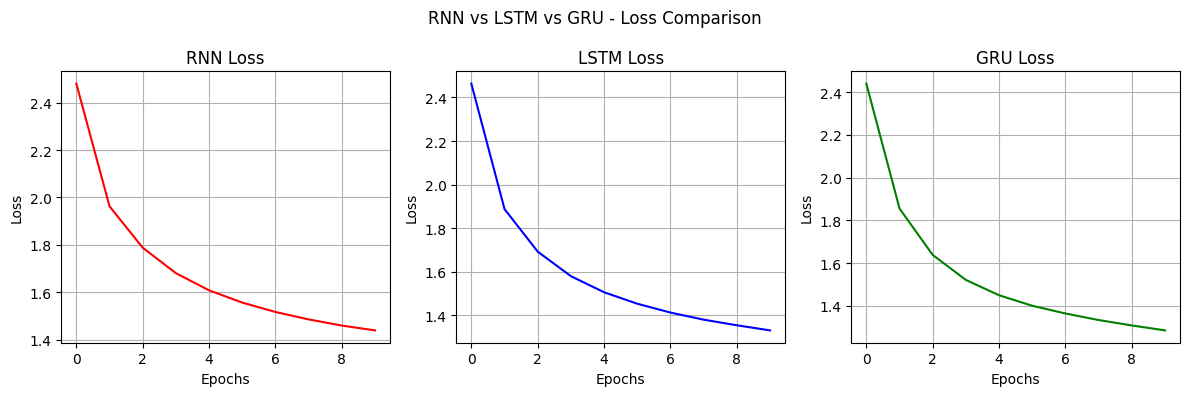

Final Losses:
RNN  Loss: 1.4391
LSTM Loss: 1.3311
GRU  Loss: 1.2858


In [12]:
import matplotlib.pyplot as plt

# Loss comparison plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(rnn_history.history['loss'], 'r')
plt.title('RNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], 'b')
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(gru_history.history['loss'], 'g')
plt.title('GRU Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.suptitle('RNN vs LSTM vs GRU - Loss Comparison')
plt.tight_layout()
plt.show()

# Final loss print
print("Final Losses:")
print(f"RNN  Loss: {rnn_history.history['loss'][-1]:.4f}")
print(f"LSTM Loss: {lstm_history.history['loss'][-1]:.4f}")
print(f"GRU  Loss: {gru_history.history['loss'][-1]:.4f}")

In [14]:
# Conclusion
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)

print(f"""
Dataset: Shakespeare Text
Total Characters: {len(text)}
Vocabulary Size: {vocab_size}
Sequence Length: {seq_length}
Epochs: 10
Embedding Dim: {embedding_dim}
RNN Units: {rnn_units}

Final Results:
─────────────────────────────
Model   │ Final Loss
─────────────────────────────
RNN     │ {rnn_history.history['loss'][-1]:.4f}
LSTM    │ {lstm_history.history['loss'][-1]:.4f}
GRU     │ {gru_history.history['loss'][-1]:.4f}
─────────────────────────────

Observations:
1. LSTM performs better than vanilla RNN
   because of its gating mechanism
2. GRU performs similar to LSTM but
   with fewer parameters
3. Vanilla RNN suffers from vanishing
   gradient problem
4. More epochs = better text generation
""")

MODEL COMPARISON SUMMARY

Dataset: Shakespeare Text
Total Characters: 1115394
Vocabulary Size: 65
Sequence Length: 100
Epochs: 10
Embedding Dim: 256
RNN Units: 512

Final Results:
─────────────────────────────
Model   │ Final Loss
─────────────────────────────
RNN     │ 1.4391
LSTM    │ 1.3311
GRU     │ 1.2858
─────────────────────────────

Observations:
1. LSTM performs better than vanilla RNN
   because of its gating mechanism
2. GRU performs similar to LSTM but 
   with fewer parameters
3. Vanilla RNN suffers from vanishing
   gradient problem
4. More epochs = better text generation

